# Explainable Customer Churn Prediction Using XAI

## Project Objective

The goal of this project is to build a machine learning model that predicts customer churn in a telecommunications company and explains the model's decisions using Explainable Artificial Intelligence methods.

The project focuses on two main questions:

1. Which customers are likely to leave the company?
2. Why are these customers predicted as high-risk?

This is important from a business perspective because churn prediction can help the company design targeted retention actions, reduce customer loss, and improve profitability.

## Business Interpretation

The model does not only predict churn. It also explains the main reasons behind churn risk.

The XAI results can help the company identify high-risk customer groups and create retention strategies.

Possible business actions include:

1. Target customers with month-to-month contracts.
2. Offer incentives for switching to one-year or two-year contracts.
3. Provide special support to customers with high monthly charges.
4. Promote automatic payment methods.
5. Improve technical support and online security services.

These actions are directly connected to the factors identified by the XAI methods.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source folder:", SRC_DIR)

Project root: C:\Users\Yuceltan Ebiri\PycharmProjects\Telco-Customer-Churn
Source folder: C:\Users\Yuceltan Ebiri\PycharmProjects\Telco-Customer-Churn\src


## Dataset Description

The dataset used in this project is the Telco Customer Churn dataset from Kaggle.

Each row represents one customer. The target variable is `Churn`, which indicates whether the customer left the company.

The dataset contains business-readable features such as:

- Contract type
- Tenure
- Monthly charges
- Total charges
- Internet service
- Online security
- Tech support
- Payment method
- Paperless billing

These features are suitable for Explainable AI because they can be understood by non-technical business stakeholders.

In [2]:
from src.config import DATA_PATH
from src.data_preprocessing import load_data

df = load_data(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df = load_data(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


## Data Cleaning

The dataset requires several cleaning steps before model training.

The following actions are performed:

1. `customerID` is removed because it is only an identifier.
2. `TotalCharges` is converted from text to numeric format.
3. Missing values in `TotalCharges` are removed.
4. The target variable `Churn` is converted into binary format:
   - Yes = 1
   - No = 0

In [6]:
from src.data_preprocessing import clean_data

df_clean = clean_data(df)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

df_clean.head()

Original shape: (7043, 21)
Cleaned shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [11]:
df_clean.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Exploratory Data Analysis

The aim of this section is to understand the main patterns in customer churn before building the model.

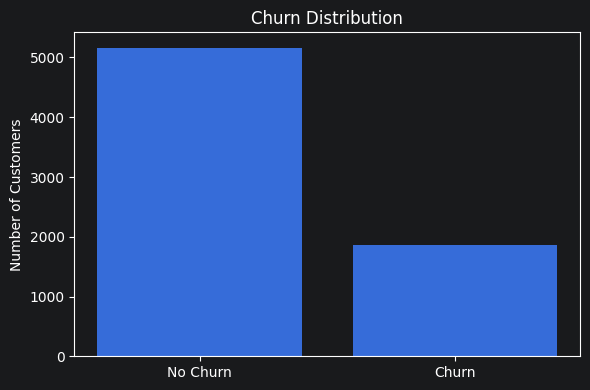

Churn
0    5163
1    1869
Name: count, dtype: int64

In [7]:
from matplotlib import pyplot as plt

churn_counts = df_clean["Churn"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["No Churn", "Churn"], churn_counts.values)
plt.title("Churn Distribution")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

churn_counts

In [8]:
churn_rate = df_clean["Churn"].mean()
print(f"Overall churn rate: {churn_rate:.2%}")

Overall churn rate: 26.58%


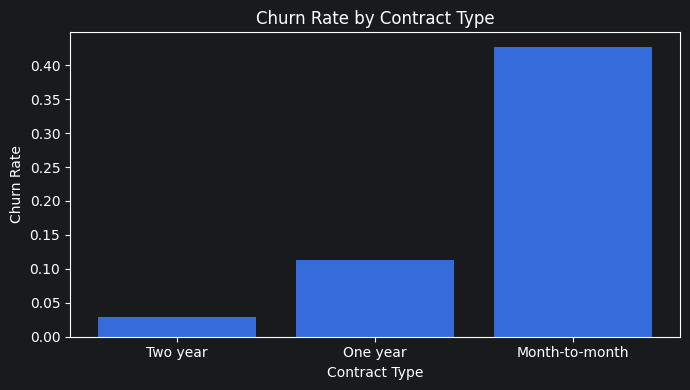

Contract
Two year          0.028487
One year          0.112772
Month-to-month    0.427097
Name: Churn, dtype: float64

In [9]:
contract_churn = df_clean.groupby("Contract")["Churn"].mean().sort_values()

plt.figure(figsize=(7, 4))
plt.bar(contract_churn.index, contract_churn.values)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.tight_layout()
plt.show()

contract_churn

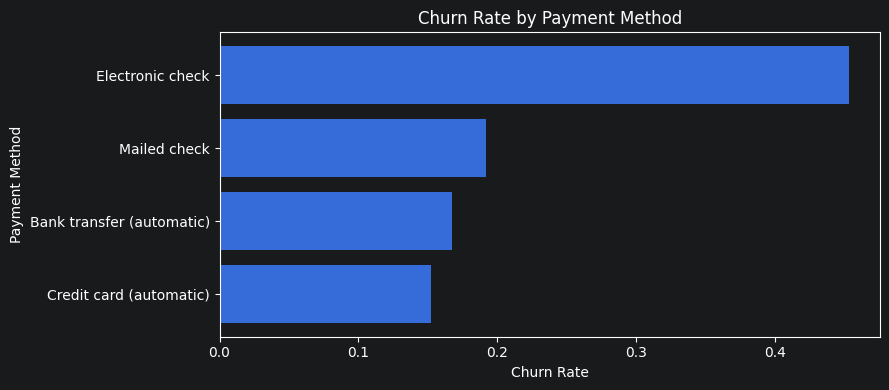

PaymentMethod
Credit card (automatic)      0.152531
Bank transfer (automatic)    0.167315
Mailed check                 0.192020
Electronic check             0.452854
Name: Churn, dtype: float64

In [10]:
payment_churn = df_clean.groupby("PaymentMethod")["Churn"].mean().sort_values()

plt.figure(figsize=(9, 4))
plt.barh(payment_churn.index, payment_churn.values)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

payment_churn

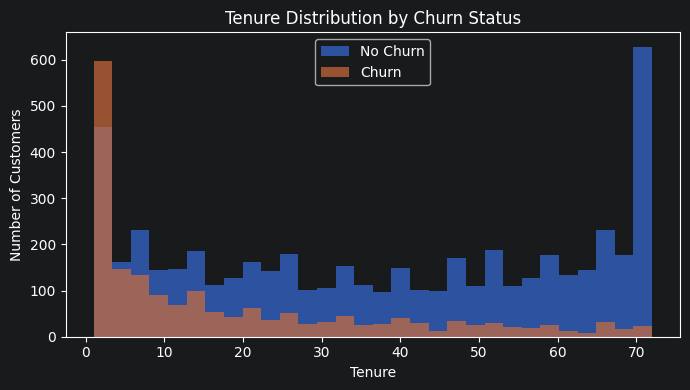

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(df_clean[df_clean["Churn"] == 0]["tenure"], bins=30, alpha=0.7, label="No Churn")
plt.hist(df_clean[df_clean["Churn"] == 1]["tenure"], bins=30, alpha=0.7, label="Churn")
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

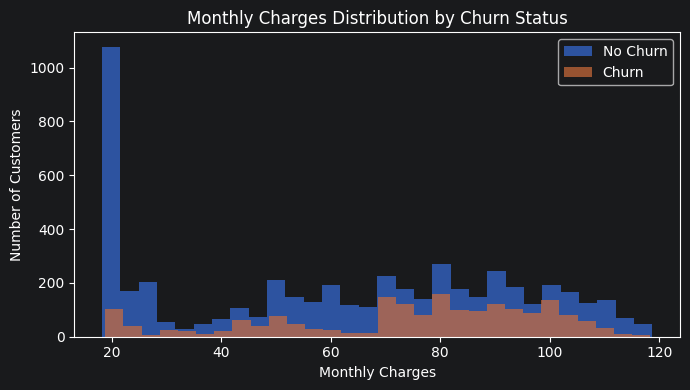

In [12]:
plt.figure(figsize=(7, 4))
plt.hist(df_clean[df_clean["Churn"] == 0]["MonthlyCharges"], bins=30, alpha=0.7, label="No Churn")
plt.hist(df_clean[df_clean["Churn"] == 1]["MonthlyCharges"], bins=30, alpha=0.7, label="Churn")
plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

## Train-Test Split and Preprocessing

The target variable is separated from the features.

The dataset is split into training and test sets using stratification. This keeps the churn ratio similar in both sets.

Numerical features are standardized, while categorical features are transformed using one-hot encoding.

In [13]:
from src.data_preprocessing import split_features_target, create_train_test_split

X, y = split_features_target(df_clean)

X_train, X_test, y_train, y_test = create_train_test_split(X, y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train churn rate:", y_train.mean())
print("y_test churn rate:", y_test.mean())

X_train shape: (5625, 19)
X_test shape: (1407, 19)
y_train churn rate: 0.2657777777777778
y_test churn rate: 0.2658137882018479


In [15]:
from src.data_preprocessing import build_preprocessor

preprocessor, numerical_features, categorical_features = build_preprocessor(X_train)

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Model Training

Two models are trained:

1. Logistic Regression
   This model is used as a baseline because it is simple and interpretable.

2. Random Forest
   This model is used as the black-box model. The main XAI methods are applied to this model.

In [16]:
from src.train_model import train_models

trained_models = train_models(preprocessor, X_train, y_train)

Training model: Logistic Regression
Training model: Random Forest


## Model Evaluation

The models are evaluated using several metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In churn prediction, recall is especially important because the company wants to identify as many customers at risk of churn as possible.

In [17]:
from src.evaluate_model import evaluate_models

metrics_df = evaluate_models(trained_models, X_test, y_test)
metrics_df

Evaluating model: Logistic Regression
Evaluating model: Random Forest


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.725657,0.490132,0.796791,0.606925,0.835134
1,Random Forest,0.766880,0.545455,0.737968,0.627273,0.831904


In [18]:
best_model_name = metrics_df.sort_values(by="ROC AUC", ascending=False).iloc[0]["Model"]
best_model_name

'Logistic Regression'

## XAI Method 1: Permutation Feature Importance

Permutation feature importance explains how important each original feature is for the model.

The logic is simple:

- A feature is randomly shuffled.
- The model performance is measured again.
- If model performance decreases strongly, the feature is important.

This method is useful for non-technical stakeholders because it provides a direct ranking of business factors influencing churn prediction.

In [19]:
from src.explain_xai import save_permutation_importance

xai_model = trained_models["Random Forest"]

permutation_importance_df = save_permutation_importance(
    xai_model,
    X_test,
    y_test
)

permutation_importance_df.head(15)

Calculating permutation importance...


,feature,importance_mean,importance_std
14,Contract,0.062463,0.009187
4,tenure,0.022539,0.004609
7,InternetService,0.020926,0.004843
18,TotalCharges,0.011665,0.003138
8,OnlineSecurity,0.005296,0.002947
11,TechSupport,0.004105,0.002014
15,PaperlessBilling,0.002510,0.002274
16,PaymentMethod,0.002198,0.001900
13,StreamingMovies,0.002036,0.001533
1,SeniorCitizen,0.000643,0.000605


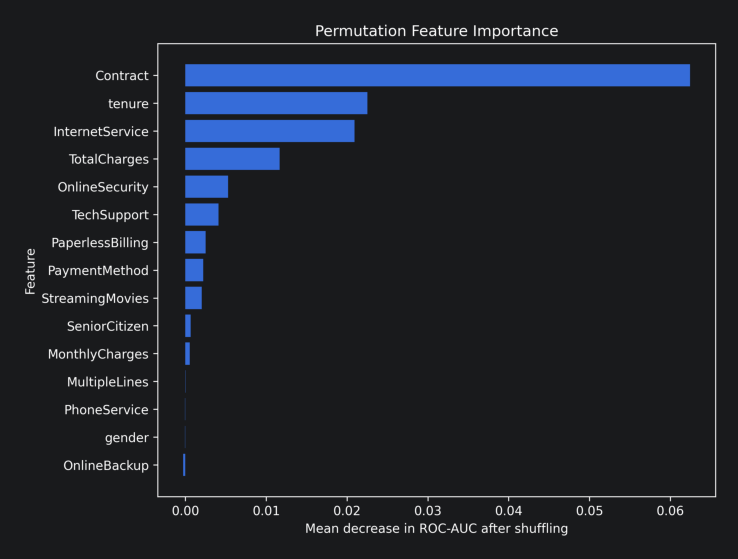

In [21]:
from src.config import FIGURES_DIR

img = plt.imread(FIGURES_DIR / "permutation_feature_importance.png")

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

## XAI Method 2: SHAP Global Explanation

SHAP explains how each feature contributes to model predictions.

A global SHAP explanation shows which features are most influential across many customers.

This allows the company to understand the general drivers.

In [22]:
from src.explain_xai import save_shap_global_explanations

shap_importance_df, explainer, X_processed_df, shap_values_churn = save_shap_global_explanations(
    xai_model,
    X_test
)

shap_importance_df.head(20)

Creating SHAP global explanations...


,feature,mean_absolute_shap
36,Contract_Month-to-month,0.077216
1,tenure,0.058857
16,InternetService_Fiber optic,0.039570
3,TotalCharges,0.037535
38,Contract_Two year,0.035840
18,OnlineSecurity_No,0.034810
27,TechSupport_No,0.026928
43,PaymentMethod_Electronic check,0.025366
2,MonthlyCharges,0.023047
15,InternetService_DSL,0.015221


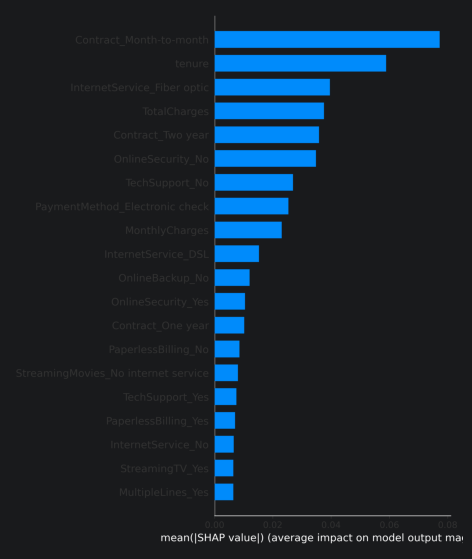

In [23]:
img = plt.imread(FIGURES_DIR / "shap_summary_bar.png")

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

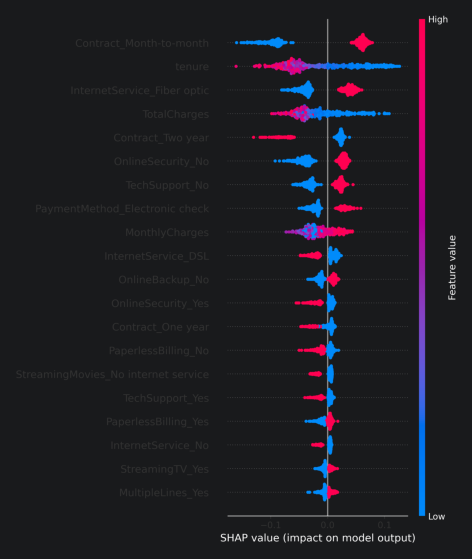

In [24]:
img = plt.imread(FIGURES_DIR / "shap_summary_beeswarm.png")

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

## XAI Method 3: SHAP Local Explanation

A local SHAP explanation explains one individual customer prediction.

This is useful because the company can understand why a specific customer is classified as high-risk.

For example, the model may predict high churn risk because a customer has:

- Month-to-month contract
- Short tenure
- High monthly charges
- No technical support
- Electronic check payment

In [25]:
from src.explain_xai import save_shap_local_explanation

highest_risk_customer = save_shap_local_explanation(
    xai_model,
    X_test
)

highest_risk_customer

Creating SHAP local explanation...


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,predicted_churn_probability
3727,Female,0,No,No,3,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,96.6,291.9,0.973404


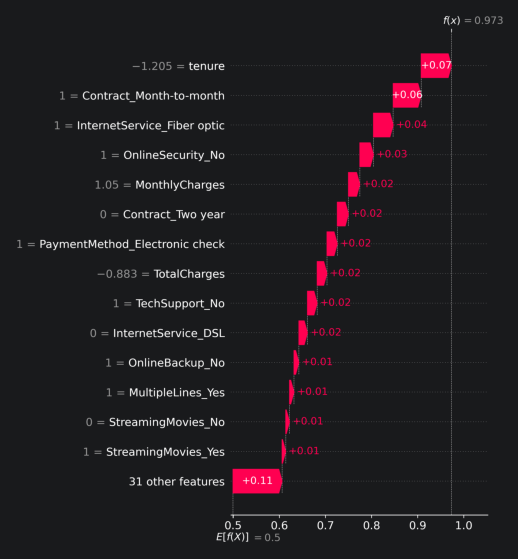

In [26]:
waterfall_path = FIGURES_DIR / "shap_local_waterfall_high_risk_customer.png"
bar_path = FIGURES_DIR / "shap_local_bar_high_risk_customer.png"

if waterfall_path.exists():
    img = plt.imread(waterfall_path)
else:
    img = plt.imread(bar_path)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

## Optional XAI Extension: What-if Analysis

A simple what-if analysis is used to estimate how the predicted churn probability changes under different possible business actions.

For example:

- What if the customer changed from a month-to-month contract to a two-year contract?
- What if the customer used automatic payment?
- What if the customer added tech support?

This is useful because it translates model explanations into possible retention actions.

In [27]:
from src.explain_xai import save_counterfactual_analysis

counterfactual_df = save_counterfactual_analysis(
    xai_model,
    X_test
)

counterfactual_df

Creating counterfactual what-if analysis...


,scenario,predicted_churn_probability,change_vs_original
0,Original customer,0.973404,0.000000
1,Change Contract to One year,0.626968,-0.346436
2,Change Contract to Two year,0.548936,-0.424468
3,Change PaymentMethod to Credit card (automatic),0.932973,-0.040432
4,Change PaymentMethod to Bank transfer (automatic),0.951343,-0.022061
5,Change OnlineSecurity to Yes,0.853290,-0.120114
6,Change TechSupport to Yes,0.878413,-0.094992
7,Change PaperlessBilling to No,0.913111,-0.060293


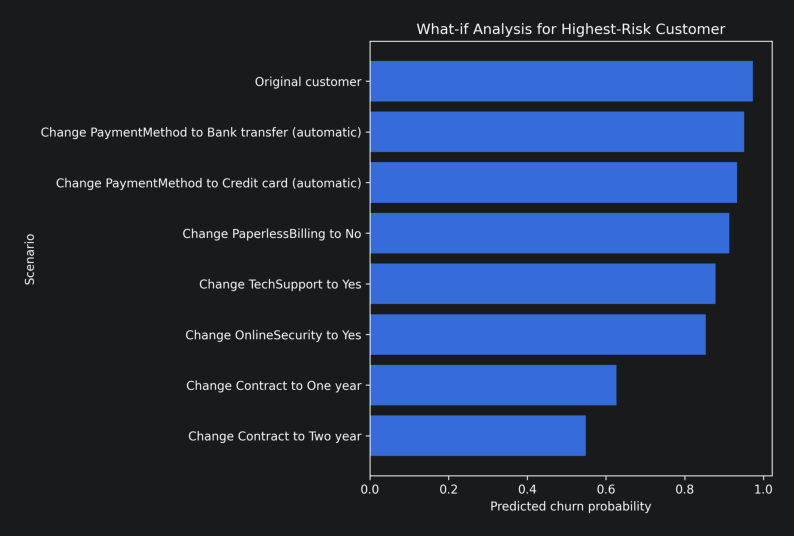

In [28]:
img = plt.imread(FIGURES_DIR / "counterfactual_what_if_analysis.png")

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

## Business Interpretation

The model does not only predict churn. It also explains the main reasons behind churn risk.

The XAI results can help the company identify high-risk customer groups and create retention strategies.

Possible business actions include:

1. Target customers with month-to-month contracts.
2. Offer incentives for switching to one-year or two-year contracts.
3. Provide special support to customers with high monthly charges.
4. Promote automatic payment methods.
5. Improve technical support and online security services.

These actions are directly connected to the factors identified by the XAI methods.

## Conclusion

This project developed a machine learning pipeline for customer churn prediction and applied Explainable AI methods to interpret the model.

The Random Forest model was used as the main black-box model. Its predictions were explained using:

- Permutation feature importance
- SHAP global explanations
- SHAP local explanations
- What-if analysis

The project shows that XAI can make machine learning results understandable and actionable for business decision-makers.

Instead of only saying which customers may churn, the model explains why they may churn and how the company can respond.